# 🎮 Lesson 1 · Building your first MuJoCo sim scene

Before we plug in a **vision-language-action** policy, let's learn the sim
API itself. This notebook walks through the basics:

1. Creating a world
2. Adding a robot from the 68-robot registry
3. Adding objects the robot will interact with
4. Stepping physics and commanding poses
5. Rendering + recording an inline MP4 video

The output at the bottom of the notebook is an **actual video** of the arm
moving — not just a static image.

## 1 · Create a simulation

`create_simulation(backend)` returns a `Simulation` object implementing the
`SimEngine` interface. `list_backends()` shows what's registered
(`mj`/`mjc`/`mjx` are aliases for the default `mujoco` backend).

In [1]:
from strands_robots.simulation import create_simulation, list_backends
print("Available backends:", list_backends())
sim = create_simulation("mujoco")
print(f"Simulation class: {type(sim).__name__}")

Available backends: ['mj', 'mjc', 'mjx', 'mujoco']


Simulation class: Simulation


## 2 · Build a world

`create_world()` compiles an empty MuJoCo scene. We then:
- Add an **SO-101** arm (a 6-DOF open-source teleop arm from The Robot Studio)
- Drop a red cube and a blue sphere as props
- Place a camera to watch the scene

All robots come from `strands_robots/registry/robots.json` — 68 robots including
SO-100/101, Franka, Unitree G1, Aloha, Apollo humanoid, etc.

In [2]:
sim.create_world(timestep=0.002, gravity=[0, 0, -9.81])

sim.add_robot(name="arm", data_config="so101", position=[0, 0, 0])
sim.add_object("red_cube",  shape="box",    position=[0.25,  0.10, 0.05],
               size=[0.02]*3, rgba=[1, 0, 0, 1])
sim.add_object("blue_ball", shape="sphere", position=[0.25, -0.10, 0.05],
               size=[0.025]*3, rgba=[0, 0, 1, 1])

# A world-frame camera aimed at the workspace
sim.add_camera("front", position=[0.25, -0.5, 0.4], target=[0.25, 0, 0.05])

print(f"robots  : {list(sim._world.robots.keys())}")
print(f"objects : {list(sim._world.objects.keys())}")
print(f"cameras : {[c.name for c in sim._world.cameras.values()]}")
print(f"joints  : {sim.robot_joint_names('arm')}")

robots  : ['arm']
objects : ['red_cube', 'blue_ball']
cameras : ['default', 'wrist_cam', 'front']
joints  : ['shoulder_pan', 'shoulder_lift', 'elbow_flex', 'wrist_flex', 'wrist_roll', 'gripper']


## 3 · Preview the initial pose

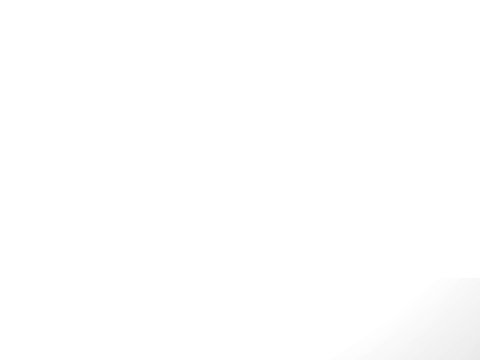

In [3]:
from IPython.display import display, Image as IPyImage

def show(sim, cam="front", w=480, h=360):
    r = sim.render(camera_name=cam, width=w, height=h)
    ib = next(c for c in r["content"] if "image" in c)
    b = ib["image"]["source"]["bytes"]
    display(IPyImage(data=b if isinstance(b, (bytes, bytearray)) else __import__('base64').b64decode(b)))

sim.step(n_steps=100)
show(sim)

## 4 · Command a pose with `send_action`

Actions are dicts mapping joint names to target positions. The sim's built-in
position actuators will drive the joints there over the next physics steps.

We'll record the whole movement into an MP4 so you can watch it inline.

In [4]:
import tempfile, pathlib
tmpdir = pathlib.Path(tempfile.mkdtemp(prefix="lesson1_"))
print("recording to:", tmpdir)

sim.start_recording(repo_id="local/lesson1", task="reach_pose",
                    fps=30, root=str(tmpdir), overwrite=True)

# Command target pose, then step — frames captured automatically between steps
target_pose = {
    "shoulder_pan":  0.4,
    "shoulder_lift": -0.5,
    "elbow_flex":    0.7,
    "wrist_flex":    0.3,
    "wrist_roll":    0.0,
    "gripper":       0.4,
}
sim.send_action(action=target_pose, robot_name="arm")

# Step physics — the recording mixin auto-captures frames between steps at `fps`
# rate. Here we run 300 physics substeps over the recording.
from strands_robots.policies.mock import MockPolicy
p = MockPolicy(); p.set_robot_state_keys(sim.robot_joint_names("arm"))
r = sim.run_policy("arm", policy_object=p,
                   instruction="move smoothly", duration=3.0, control_frequency=30.0)
print("run_policy:", r["status"])
sim.stop_recording()

print("\n-- dataset tree --")
for f in sorted(tmpdir.rglob("*")):
    if f.is_file():
        print(f"  {f.relative_to(tmpdir)} ({f.stat().st_size:,} bytes)")

recording to: /var/folders/nt/_7cw350j3732__h0xtsnjmtm0000gq/T/lesson1_scf4whdp


run_policy: success


Map:   0%|          | 0/90 [00:00<?, ? examples/s]


-- dataset tree --
  data/chunk-000/file-000.parquet (8,175 bytes)
  meta/episodes/chunk-000/file-000.parquet (61,440 bytes)
  meta/info.json (3,813 bytes)
  meta/stats.json (16,121 bytes)
  meta/tasks.parquet (2,048 bytes)
  videos/observation.images.arm__wrist_cam/chunk-000/file-000.mp4 (309,804 bytes)
  videos/observation.images.default/chunk-000/file-000.mp4 (72,629 bytes)
  videos/observation.images.front/chunk-000/file-000.mp4 (9,269 bytes)


## 5 · Watch the arm move — inline video

Embed the recorded MP4 directly in the notebook. This is the MuJoCo
simulation running with real physics, rendered to video via ffmpeg/SVT-AV1.

In [5]:
from IPython.display import Video

front_mp4 = tmpdir / "videos" / "observation.images.front" / "chunk-000" / "file-000.mp4"
print(f"front video: {front_mp4} ({front_mp4.stat().st_size:,} bytes)")

# Embed it with base64 so the notebook is self-contained
Video(str(front_mp4), embed=True, html_attributes="controls loop")

front video: /var/folders/nt/_7cw350j3732__h0xtsnjmtm0000gq/T/lesson1_scf4whdp/videos/observation.images.front/chunk-000/file-000.mp4 (9,269 bytes)


## 6 · Same rollout from the wrist camera

The sim auto-attached a wrist camera to the arm (`arm/wrist_cam`). Policies
usually consume this as their primary visual input — it's the frame a
vision-language-action model (like SmolVLA) will see in **Lesson 2**.

In [6]:
wrist_mp4 = tmpdir / "videos" / "observation.images.arm__wrist_cam" / "chunk-000" / "file-000.mp4"
if wrist_mp4.exists():
    print(f"wrist video: {wrist_mp4.stat().st_size:,} bytes")
    display(Video(str(wrist_mp4), embed=True, html_attributes="controls loop"))
else:
    print("no wrist cam video (sim may not expose the attached cam for this robot)")

wrist video: 309,804 bytes


## 7 · Observations — what a policy receives

`get_observation(robot)` is the dict a `Policy` consumes on each step.
Float joint positions + HxWx3 uint8 camera arrays — this is the "state" input
to the VLA we'll load next notebook.

In [7]:
obs = sim.get_observation("arm")
for k, v in obs.items():
    if hasattr(v, "shape"):
        print(f"  {k:25s} ndarray shape={v.shape} dtype={v.dtype}")
    else:
        print(f"  {k:25s} {type(v).__name__} = {v!r:.40}")

  shoulder_pan              float = 0.39598655331663524
  shoulder_lift             float = 0.09778935155210985
  elbow_flex                float = 0.043207216357869435
  wrist_flex                float = -0.031016204786306043
  wrist_roll                float = -0.04971189190044907
  gripper                   float = 0.06531901692003157
  default                   ndarray shape=(480, 640, 3) dtype=uint8
  front                     ndarray shape=(480, 640, 3) dtype=uint8
  arm/wrist_cam             ndarray shape=(480, 640, 3) dtype=uint8
  wrist_cam                 ndarray shape=(480, 640, 3) dtype=uint8


## 8 · Tear down

In [8]:
sim.destroy()
print("sim destroyed ✓")

sim destroyed ✓


---
### Key takeaways

* **`Simulation`** is a Strands `AgentTool` with 35 actions — `create_world`,
  `add_robot`, `step`, `render`, `send_action`, `run_policy`, `start_recording`…
* Scenes are built **imperatively** — robots, objects, cameras added one at
  a time; an XML round-trip keeps the MuJoCo model in sync.
* **`run_policy`** orchestrates the observe→act→step loop and feeds frames
  to the recorder if one is active.
* Recording produces a full **LeRobot v3 dataset** (parquet + per-camera MP4)
  — directly trainable.

### Next

→ [**Lesson 2 — SmolVLA inference in sim**](02_vla_inference.ipynb) — load a
real vision-language-action model and watch it drive the arm from natural
language instructions.